# Task 02: Titanic Dataset EDA & Data Cleaning

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the Titanic dataset from a reliable public source
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
titanic_df = pd.read_csv(url)

# 2. View the first 5 rows to see what columns we have
print("--- Titanic Dataset Preview ---")
display(titanic_df.head())

# 3. Check the shape (rows and columns) and data types
print("\n--- Dataset Summary ---")
titanic_df.info()

--- Titanic Dataset Preview ---


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



--- Dataset Summary ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [3]:
# Check exactly how many missing values are in each column
print("--- Missing Values Per Column ---")
print(titanic_df.isnull().sum())

--- Missing Values Per Column ---
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [4]:
# 1. Fill missing Age values with the median age
titanic_df['Age'].fillna(titanic_df['Age'].median(), inplace=True)

# 2. Fill missing Embarked values with the most common port ('S')
titanic_df['Embarked'].fillna(titanic_df['Embarked'].mode()[0], inplace=True)

# 3. Drop the Cabin column since it has too many missing values
titanic_df.drop(columns=['Cabin'], inplace=True)

# 4. Verify that our dataset is now completely clean!
print("--- Missing Values After Cleaning ---")
print(titanic_df.isnull().sum())

--- Missing Values After Cleaning ---
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


/tmp/ipykernel_11162/3151121053.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_df['Age'].fillna(titanic_df['Age'].median(), inplace=True)
/tmp/ipykernel_11162/3151121053.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, 

/tmp/ipykernel_11162/286826016.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=titanic_df, ax=axes[0], palette='pastel', ci=None)
/tmp/ipykernel_11162/286826016.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=titanic_df, ax=axes[0], palette='pastel', ci=None)
/tmp/ipykernel_11162/286826016.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=titanic_df, ax=axes[1], palette='muted', ci=None)
/tmp/ipykernel_11162/286826016.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='

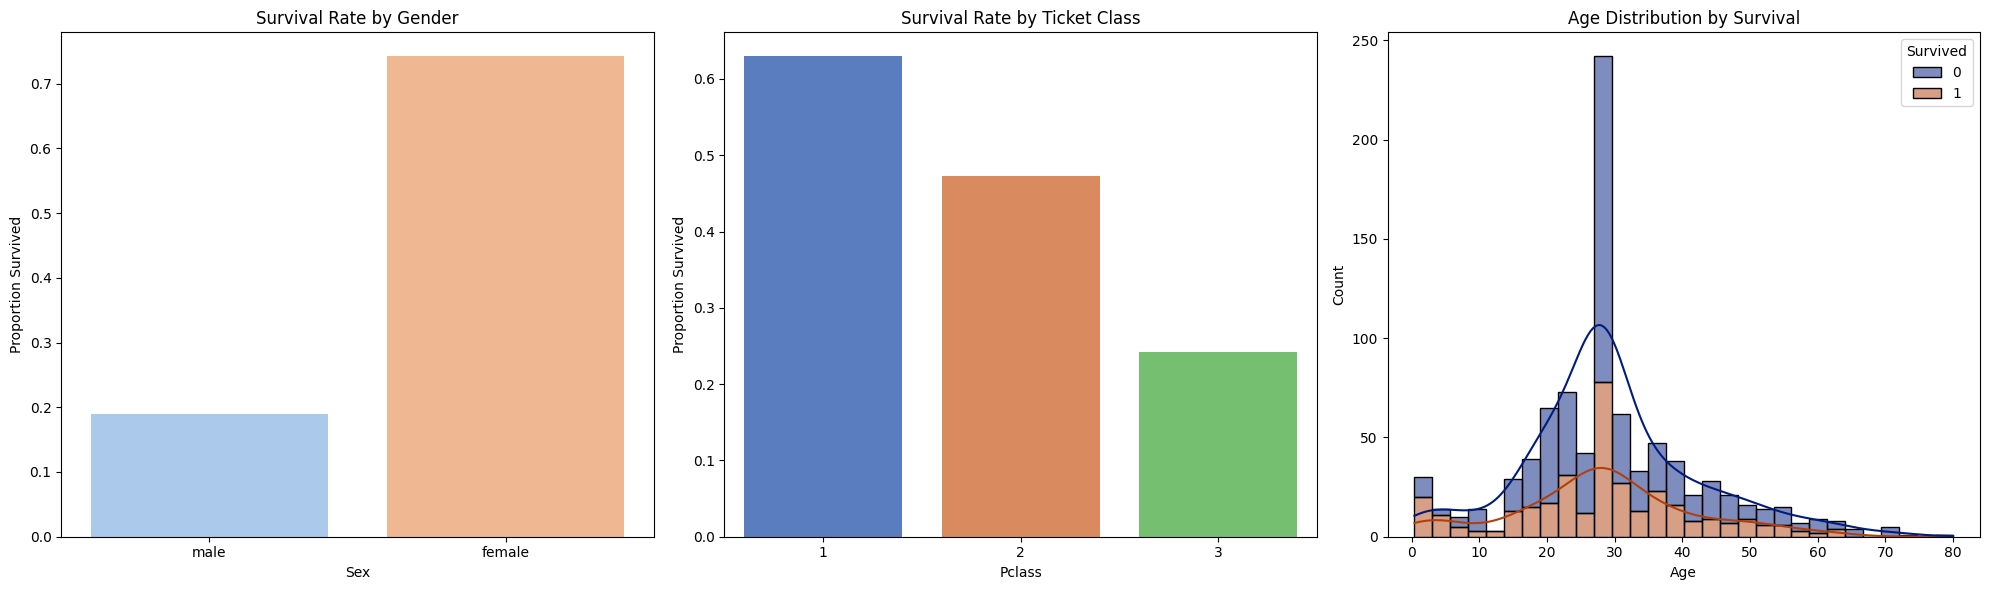

In [5]:
# Set up a 1-row, 3-column layout for our charts
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Chart 1: Survival Rate by Gender
sns.barplot(x='Sex', y='Survived', data=titanic_df, ax=axes[0], palette='pastel', ci=None)
axes[0].set_title('Survival Rate by Gender')
axes[0].set_ylabel('Proportion Survived')

# Chart 2: Survival Rate by Passenger Class (1st, 2nd, 3rd class)
sns.barplot(x='Pclass', y='Survived', data=titanic_df, ax=axes[1], palette='muted', ci=None)
axes[1].set_title('Survival Rate by Ticket Class')
axes[1].set_ylabel('Proportion Survived')

# Chart 3: Age Distribution of Survivors vs Non-Survivors
sns.histplot(data=titanic_df, x='Age', hue='Survived', kde=True, multiple='stack', ax=axes[2], palette='dark')
axes[2].set_title('Age Distribution by Survival')

# Clean up layout and display
plt.tight_layout()
plt.show()

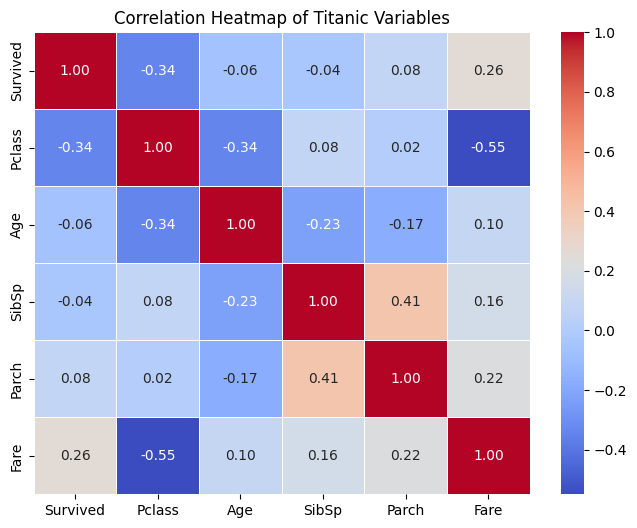

In [6]:
# 1. Select only the numerical columns for correlation analysis
numerical_cols = titanic_df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']]

# 2. Calculate the correlation matrix
corr_matrix = numerical_cols.corr()

# 3. Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Titanic Variables')
plt.show()